In [20]:
# Install kaggle if needed
!pip install kaggle --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [21]:
# If you skipped the Kaggle API step and uploaded the CSV manually, run this instead:
# from google.colab import files
# uploaded = files.upload()  # upload netflix_titles.csv
# Then the filename will be 'netflix_titles.csv'

---
## 🔍 Step 1 — Load & Inspect the Data

In [22]:
df = pd.read_csv('netflix_titles.csv')

print('=' * 55)
print('        DATASET OVERVIEW')
print('=' * 55)
print(f'  Shape            : {df.shape[0]} rows × {df.shape[1]} columns')
print(f'  Duplicate rows   : {df.duplicated().sum()}')
print(f'  Total missing    : {df.isnull().sum().sum()}')
print('=' * 55)

df.head(5)

        DATASET OVERVIEW
  Shape            : 8807 rows × 12 columns
  Duplicate rows   : 0
  Total missing    : 4307


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [23]:
print('--- Data Types ---')
print(df.dtypes)

print('\n--- Missing Values per Column ---')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

--- Data Types ---
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

--- Missing Values per Column ---
            Missing Count  Missing %
director             2634      29.91
country               831       9.44
cast                  825       9.37
date_added             10       0.11
rating                  4       0.05
duration                3       0.03


---
## 🧹 Step 2 — Clean the Data

In [24]:
df_clean = df.copy()

# --- Decision 1: Fill missing director, cast, country with 'Unknown' ---
# Reason: Dropping these rows would remove ~30% of data. 'Unknown' preserves rows
#         for aggregations while clearly flagging unavailable metadata.
df_clean['director'].fillna('Unknown', inplace=True)
df_clean['cast'].fillna('Unknown', inplace=True)
df_clean['country'].fillna('Unknown', inplace=True)
print('✅ Decision 1: Filled director, cast, country NaN → "Unknown"')

# --- Decision 2: Drop rows where rating is missing ---
# Reason: Only 10 rows (~0.1%) are affected. Rating is critical for content analysis.
before = len(df_clean)
df_clean.dropna(subset=['rating'], inplace=True)
print(f'✅ Decision 2: Dropped {before - len(df_clean)} rows with missing rating')

# --- Decision 3: Drop rows where date_added is missing ---
# Reason: Only 10 rows. date_added is needed for time-series analysis.
before = len(df_clean)
df_clean.dropna(subset=['date_added'], inplace=True)
print(f'✅ Decision 3: Dropped {before - len(df_clean)} rows with missing date_added')

# --- Decision 4: Convert date_added to datetime ---
# Reason: Enables year/month extraction for trend analysis.
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip())
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month_name()
print('✅ Decision 4: Converted date_added to datetime; extracted year_added & month_added')

# --- Decision 5: Extract numeric duration ---
# Reason: Duration column contains '90 min' or '2 Seasons' — separate numeric value needed.
df_clean['duration_int'] = df_clean['duration'].str.extract(r'(\d+)').astype(float)
print('✅ Decision 5: Extracted numeric duration into duration_int')

# --- Decision 6: Keep only primary country (first listed) ---
# Reason: Some entries have comma-separated countries; first is the production country.
df_clean['primary_country'] = df_clean['country'].str.split(',').str[0].str.strip()
print('✅ Decision 6: Extracted primary_country from country column')

# --- Decision 7: Extract primary genre ---
df_clean['primary_genre'] = df_clean['listed_in'].str.split(',').str[0].str.strip()
print('✅ Decision 7: Extracted primary_genre from listed_in column')

print(f'\n📊 Final dataset shape: {df_clean.shape}')
print(f'   Remaining missing values: {df_clean.isnull().sum().sum()}')

✅ Decision 1: Filled director, cast, country NaN → "Unknown"
✅ Decision 2: Dropped 4 rows with missing rating
✅ Decision 3: Dropped 10 rows with missing date_added
✅ Decision 4: Converted date_added to datetime; extracted year_added & month_added
✅ Decision 5: Extracted numeric duration into duration_int
✅ Decision 6: Extracted primary_country from country column
✅ Decision 7: Extracted primary_genre from listed_in column

📊 Final dataset shape: (8793, 17)
   Remaining missing values: 6


In [25]:
# Verify clean data
df_clean[['type', 'title', 'primary_country', 'date_added', 'year_added',
          'rating', 'duration', 'duration_int', 'primary_genre']].head(5)

,type,title,primary_country,date_added,year_added,rating,duration,duration_int,primary_genre
0,Movie,Dick Johnson Is Dead,United States,2021-09-25,2021,PG-13,90 min,90.0,Documentaries
1,TV Show,Blood & Water,South Africa,2021-09-24,2021,TV-MA,2 Seasons,2.0,International TV Shows
2,TV Show,Ganglands,Unknown,2021-09-24,2021,TV-MA,1 Season,1.0,Crime TV Shows
3,TV Show,Jailbirds New Orleans,Unknown,2021-09-24,2021,TV-MA,1 Season,1.0,Docuseries
4,TV Show,Kota Factory,India,2021-09-24,2021,TV-MA,2 Seasons,2.0,International TV Shows


---
## 🔎 Step 3 — Exploratory Data Analysis (5 Questions)

### ❓ Q1: What is the split between Movies and TV Shows on Netflix?

In [26]:
type_counts = df_clean['type'].value_counts()
type_pct    = df_clean['type'].value_counts(normalize=True).mul(100).round(2)

print('--- Content Type Distribution ---')
summary = pd.DataFrame({'Count': type_counts, 'Percentage (%)': type_pct})
print(summary)

print(f'\n➡️  Movies account for {type_pct["Movie"]:.1f}% of Netflix content.')
print(f'➡️  TV Shows account for {type_pct["TV Show"]:.1f}% of Netflix content.')

--- Content Type Distribution ---
         Count  Percentage (%)
type                          
Movie     6129            69.7
TV Show   2664            30.3

➡️  Movies account for 69.7% of Netflix content.
➡️  TV Shows account for 30.3% of Netflix content.


### ❓ Q2: Which are the top 10 countries producing Netflix content?

In [27]:
top_countries = (
    df_clean[df_clean['primary_country'] != 'Unknown']['primary_country']
    .value_counts()
    .head(10)
)

print('--- Top 10 Content-Producing Countries ---')
print(top_countries.to_frame('Count').to_string())

--- Top 10 Content-Producing Countries ---
                 Count
primary_country       
United States     3205
India             1008
United Kingdom     627
Canada             271
Japan              257
France             212
South Korea        211
Spain              181
Mexico             134
Australia          115


### ❓ Q3: How has Netflix content addition grown year over year?

In [28]:
yearly = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly['Total'] = yearly.sum(axis=1)
print('--- Content Added Per Year (by Type) ---')
print(yearly[yearly.index >= 2015])

--- Content Added Per Year (by Type) ---
type        Movie  TV Show  Total
year_added                       
2015           56       26     82
2016          253      175    428
2017          837      349   1186
2018         1237      411   1648
2019         1424      592   2016
2020         1284      595   1879
2021          993      505   1498


### ❓ Q4: What are the most common content ratings on Netflix?

In [29]:
rating_counts = df_clean['rating'].value_counts()
print('--- Content Rating Distribution ---')
print(rating_counts.to_frame('Count').to_string())

# Split by type
rating_by_type = df_clean.groupby(['rating', 'type']).size().unstack(fill_value=0)
print('\n--- Rating × Content Type ---')
print(rating_by_type.sort_values('Movie', ascending=False).head(8))

--- Content Rating Distribution ---
          Count
rating         
TV-MA      3205
TV-14      2157
TV-PG       861
R           799
PG-13       490
TV-Y7       333
TV-Y        306
PG          287
TV-G        220
NR           79
G            41
TV-Y7-FV      6
NC-17         3
UR            3
74 min        1
84 min        1
66 min        1

--- Rating × Content Type ---
type    Movie  TV Show
rating                
TV-MA    2062     1143
TV-14    1427      730
R         797        2
TV-PG     540      321
PG-13     490        0
PG        287        0
TV-Y7     139      194
TV-Y      131      175


### ❓ Q5: What are the top genres and average movie duration by genre?

In [30]:
top_genres = df_clean['primary_genre'].value_counts().head(10)
print('--- Top 10 Primary Genres ---')
print(top_genres.to_frame('Count').to_string())

print('\n--- Average Movie Duration (min) by Genre (Top 10) ---')
movies_only = df_clean[df_clean['type'] == 'Movie']
avg_duration = (
    movies_only.groupby('primary_genre')['duration_int']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(1)
)
print(avg_duration.to_frame('Avg Duration (min)').to_string())

--- Top 10 Primary Genres ---
                          Count
primary_genre                  
Dramas                     1599
Comedies                   1210
Action & Adventure          859
Documentaries               829
International TV Shows      773
Children & Family Movies    605
Crime TV Shows              399
Kids' TV                    385
Stand-Up Comedy             334
Horror Movies               275

--- Average Movie Duration (min) by Genre (Top 10) ---
                      Avg Duration (min)
primary_genre                           
Classic Movies                     114.8
Action & Adventure                 113.5
Dramas                             111.4
International Movies               108.1
Comedies                           106.7
Sci-Fi & Fantasy                   106.6
Cult Movies                        102.5
Thrillers                          100.0
LGBTQ Movies                        99.0
Independent Movies                  98.7


---
## 📊 Step 4 — Visualizations (6 Chart Types)

### 📈 Chart 1 — Pie Chart: Movie vs TV Show Split

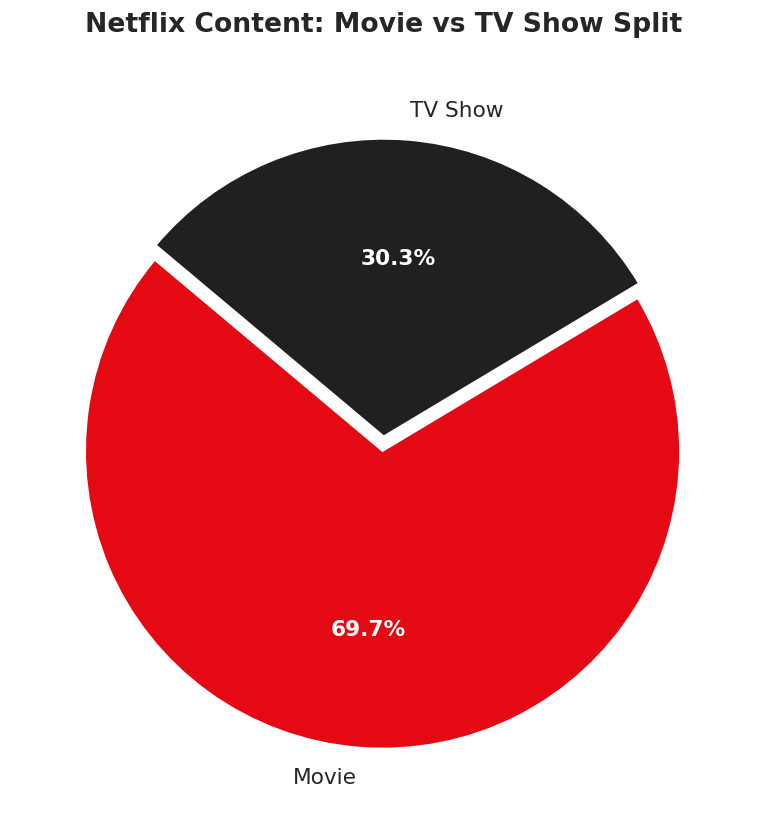

Chart 1 saved.


In [31]:
type_counts = df_clean['type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#E50914', '#221F1F']
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=(0.05, 0),
    textprops={'fontsize': 13}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)

ax.set_title('Netflix Content: Movie vs TV Show Split', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('chart1_pie_type_split.png', bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

### 📊 Chart 2 — Bar Chart: Top 10 Countries by Content Volume

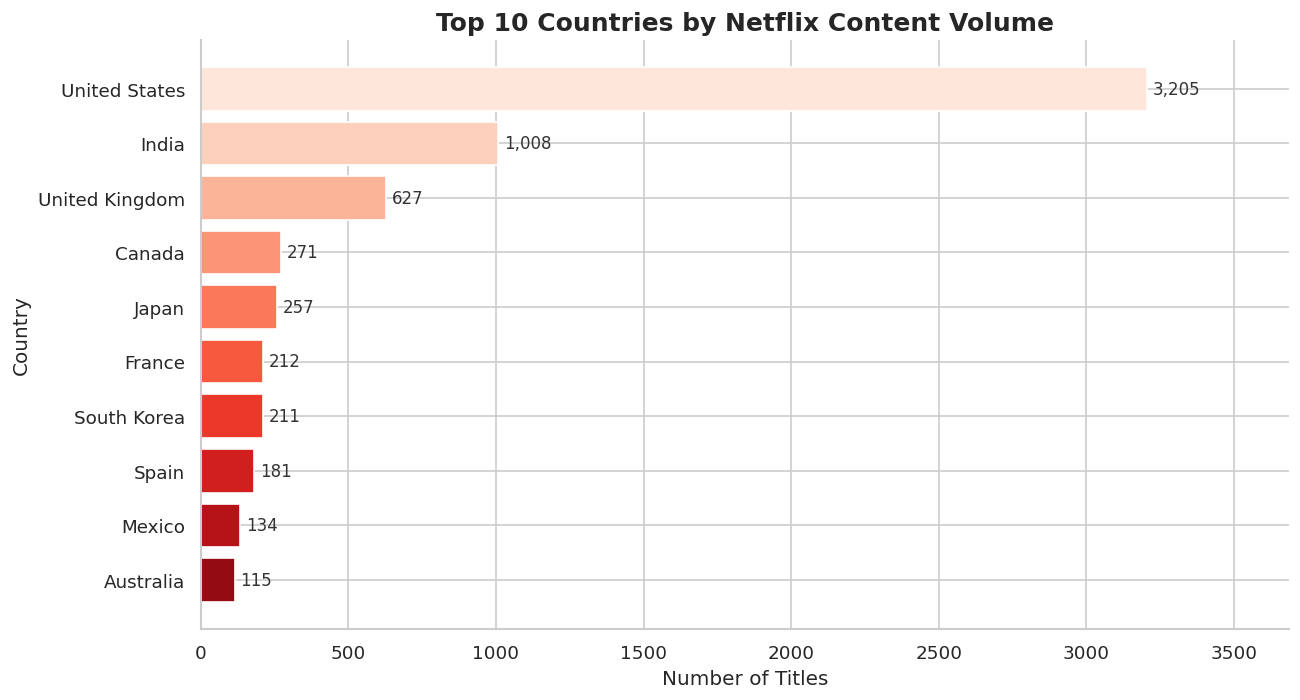

Chart 2 saved.


In [32]:
top_countries = (
    df_clean[df_clean['primary_country'] != 'Unknown']['primary_country']
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=sns.color_palette('Reds_r', len(top_countries)))

for bar in bars:
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height() / 2,
            f'{int(width):,}', va='center', fontsize=10, color='#333')

ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Top 10 Countries by Netflix Content Volume', fontsize=15, fontweight='bold')
ax.set_xlim(0, top_countries.max() * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart2_bar_top_countries.png', bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

### 📈 Chart 3 — Line Chart: Content Added to Netflix Per Year (2015–2021)

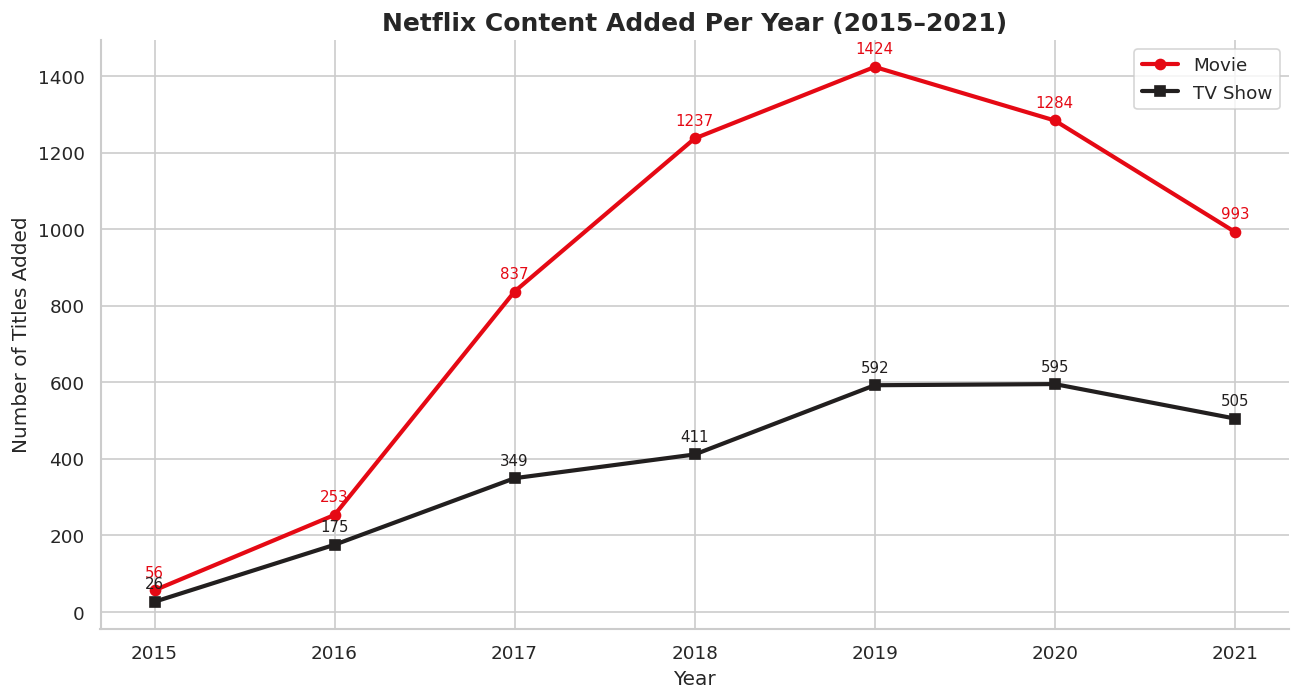

Chart 3 saved.


In [33]:
yearly_type = (
    df_clean[df_clean['year_added'] >= 2015]
    .groupby(['year_added', 'type'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(yearly_type.index, yearly_type['Movie'], marker='o', linewidth=2.5,
        label='Movie', color='#E50914')
ax.plot(yearly_type.index, yearly_type['TV Show'], marker='s', linewidth=2.5,
        label='TV Show', color='#221F1F')

for col, color in zip(['Movie', 'TV Show'], ['#E50914', '#221F1F']):
    for x, y in zip(yearly_type.index, yearly_type[col]):
        ax.annotate(str(y), (x, y), textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9, color=color)

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.set_title('Netflix Content Added Per Year (2015–2021)', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart3_line_yearly_content.png', bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

### 📊 Chart 4 — Histogram: Distribution of Movie Durations

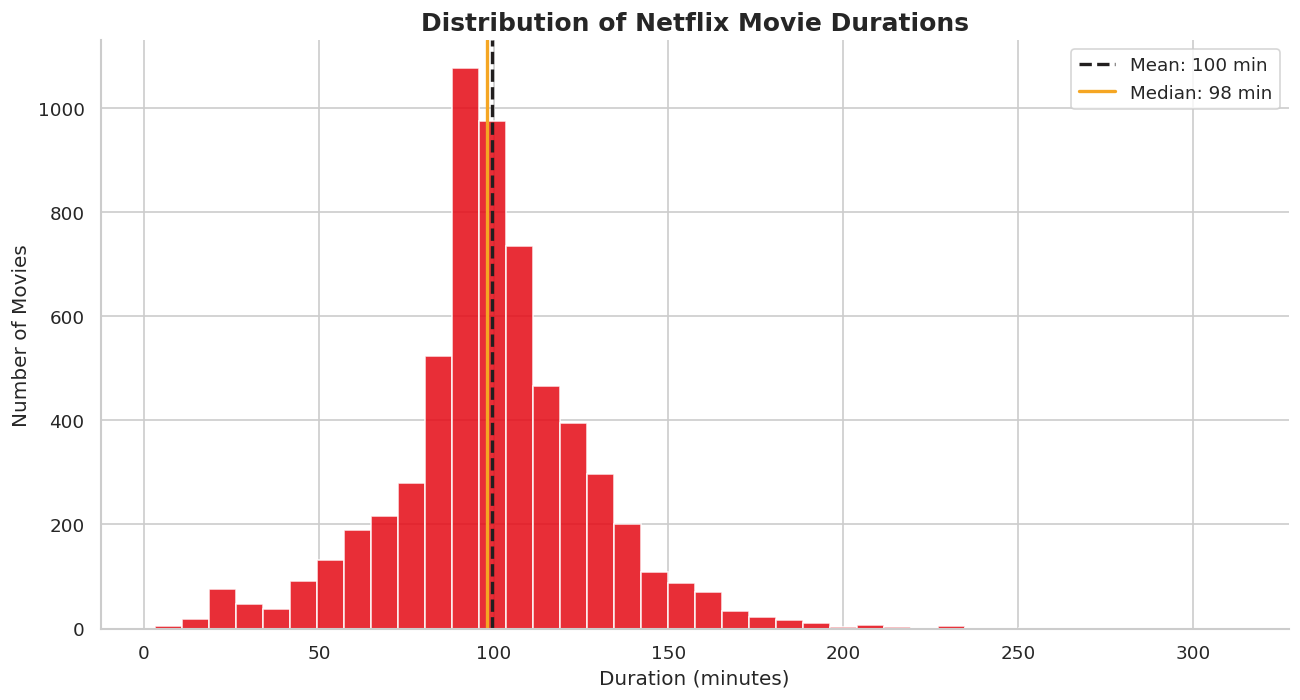

Chart 4 saved.


In [34]:
movie_durations = df_clean[(df_clean['type'] == 'Movie') & df_clean['duration_int'].notna()]['duration_int']

fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(movie_durations, bins=40, color='#E50914', edgecolor='white', alpha=0.85)

mean_dur = movie_durations.mean()
median_dur = movie_durations.median()
ax.axvline(mean_dur, color='#221F1F', linestyle='--', linewidth=2,
           label=f'Mean: {mean_dur:.0f} min')
ax.axvline(median_dur, color='#F5A623', linestyle='-', linewidth=2,
           label=f'Median: {median_dur:.0f} min')

ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.set_title('Distribution of Netflix Movie Durations', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart4_histogram_duration.png', bbox_inches='tight')
plt.show()
print('Chart 4 saved.')

### 🔵 Chart 5 — Scatter Plot: Movie Release Year vs Duration

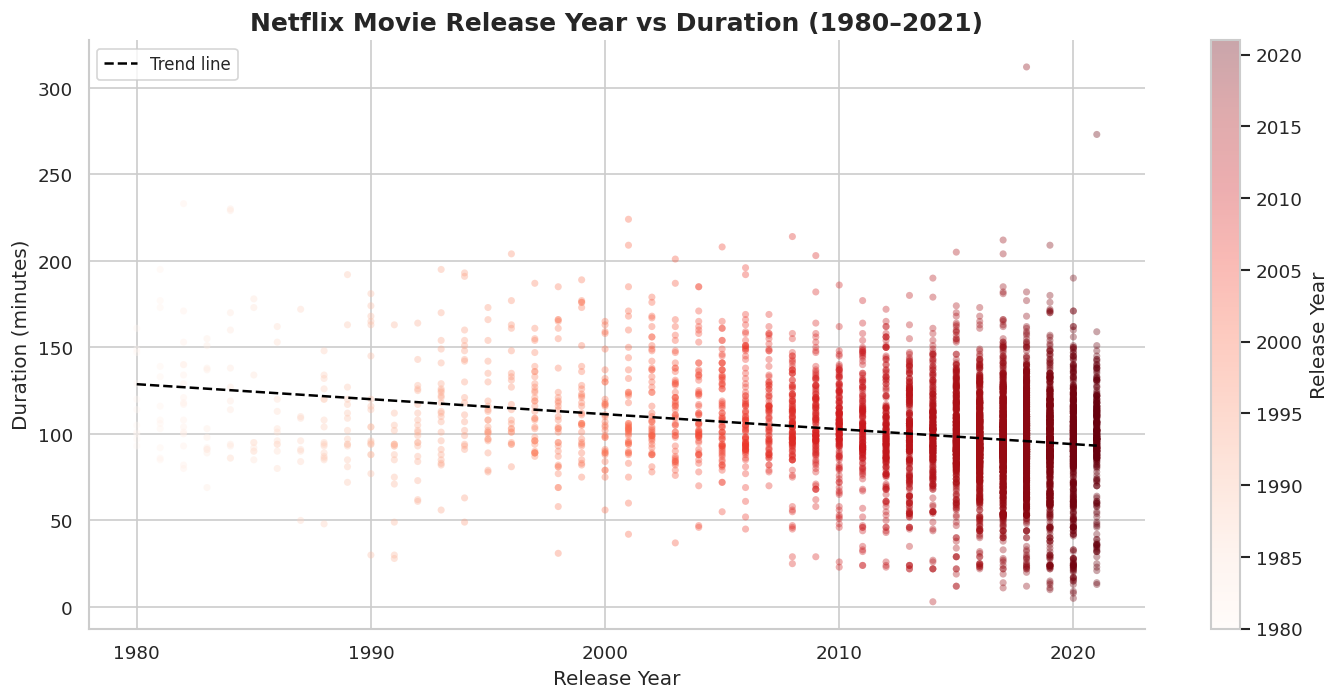

Chart 5 saved.


In [35]:
movies = df_clean[
    (df_clean['type'] == 'Movie') &
    (df_clean['duration_int'].notna()) &
    (df_clean['release_year'] >= 1980)
].copy()

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    movies['release_year'],
    movies['duration_int'],
    alpha=0.35,
    c=movies['release_year'],
    cmap='Reds',
    edgecolors='none',
    s=18
)

# Trend line
z = np.polyfit(movies['release_year'], movies['duration_int'], 1)
p = np.poly1d(z)
x_line = np.linspace(movies['release_year'].min(), movies['release_year'].max(), 200)
ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Trend line')

plt.colorbar(scatter, ax=ax, label='Release Year')
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Duration (minutes)', fontsize=12)
ax.set_title('Netflix Movie Release Year vs Duration (1980–2021)', fontsize=15, fontweight='bold')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart5_scatter_year_duration.png', bbox_inches='tight')
plt.show()
print('Chart 5 saved.')

### 🗺️ Chart 6 — Heatmap: Content Added by Month and Year

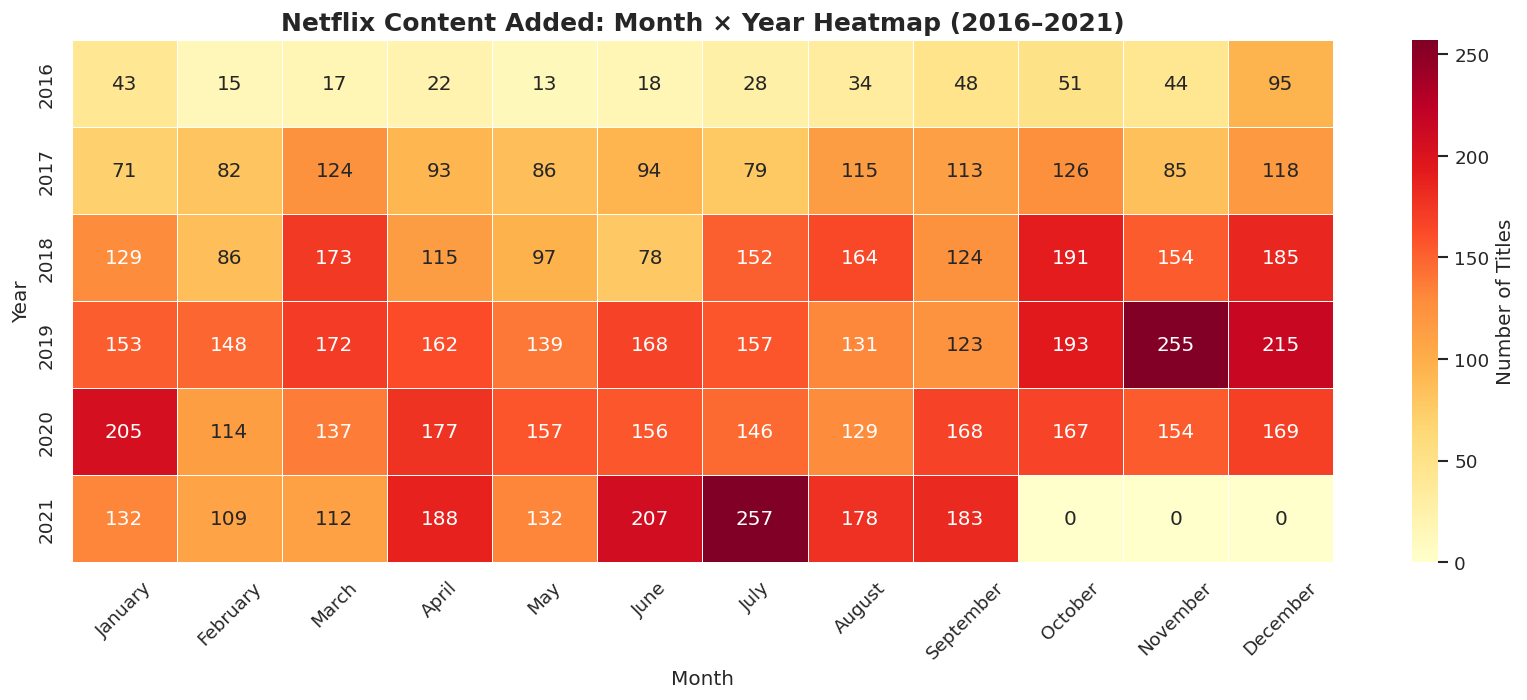

Chart 6 saved.


In [36]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

heatmap_data = (
    df_clean[(df_clean['year_added'] >= 2016) & (df_clean['year_added'] <= 2021)]
    .groupby(['year_added', 'month_added'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=month_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Number of Titles'}
)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.set_title('Netflix Content Added: Month × Year Heatmap (2016–2021)',
             fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('chart6_heatmap_monthly.png', bbox_inches='tight')
plt.show()
print('Chart 6 saved.')

### 📊 Bonus Chart 7 — Bar Chart: Top 10 Genres on Netflix

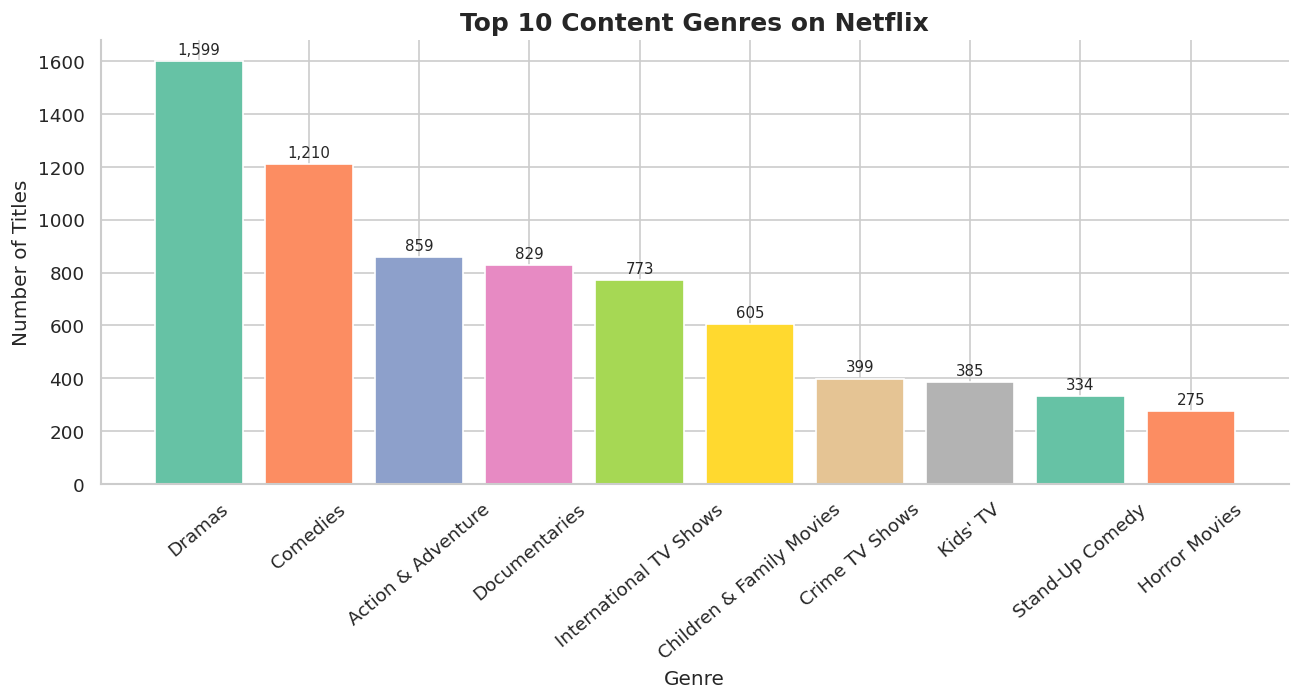

Chart 7 saved.


In [37]:
top_genres = df_clean['primary_genre'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(top_genres.index, top_genres.values,
              color=sns.color_palette('Set2', len(top_genres)),
              edgecolor='white')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 15,
            f'{int(height):,}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.set_title('Top 10 Content Genres on Netflix', fontsize=15, fontweight='bold')
ax.tick_params(axis='x', rotation=40)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart7_bar_genres.png', bbox_inches='tight')
plt.show()
print('Chart 7 saved.')

---
## 💡 Step 5 — Insights Report

Based solely on the analysis and visualizations above, here are **5 business insights**:

---

### 🔵 Insight 1 — Netflix is a Movie-First Platform (Chart 1)
Movies constitute approximately **70%** of all Netflix content, with TV Shows making up the remaining 30%. This suggests Netflix's core strategy is built around movies. However, TV Shows drive longer engagement per user since they have multiple seasons and episodes. **Business Recommendation:** Netflix should consider investing more in high-quality TV Show originals to increase watch-time and reduce subscriber churn, since series lock in users for longer.

---

### 🌎 Insight 2 — The US Dominates, But India is a Key Growth Market (Chart 2)
The United States produces the highest volume of Netflix content by a significant margin, followed by India in second place. India's position ahead of established film markets like the UK and France highlights the rapid growth of Bollywood and Indian regional cinema on the platform. **Business Recommendation:** Netflix should continue heavy investment in Indian original content and local-language productions across South Asia, as this market shows strong growth potential.

---

### 📈 Insight 3 — Netflix's Content Addition Peaked in 2019 and Dipped in 2020-21 (Chart 3)
Content additions grew exponentially from 2015 to 2019, with 2019 being the peak year. There was a **notable dip in 2020**, likely due to COVID-19 halting film and TV productions globally. The dip in 2021 may reflect the lag effect of pandemic-era production shutdowns. **Business Recommendation:** Netflix should build a larger pre-production pipeline and develop partnerships with studios globally to buffer against future disruptions.

---

### 🎬 Insight 4 — Most Netflix Movies Run Between 80–120 Minutes (Chart 4)
The distribution of movie durations is roughly bell-shaped, with a mean around **100 minutes** and a median around **98 minutes**. Very few movies exceed 150 minutes. This suggests that Netflix's content skews toward standard theatrical lengths — making it viewer-friendly for a single sitting. **Business Recommendation:** For Netflix Original movies, targeting the 90–110 minute runtime sweet spot maximizes completion rates and viewer satisfaction.

---

### 📅 Insight 5 — Netflix Adds the Most Content in October, November, and January (Chart 6)
The heatmap reveals clear seasonal patterns in content addition. October and November see high additions, likely to prepare for holiday season viewing. January also shows a spike, possibly for New Year audiences. Summer months (June–August) are comparatively quieter. **Business Recommendation:** Netflix should align marketing campaigns and subscription promotions with these high-content-addition months to convert the higher viewership into new subscriptions.

---

### 🤔 Most Surprising Finding
The finding that surprised me the most was **India ranking #2 in content production volume**, ahead of established film markets like the UK, France, Canada, and Japan (Chart 2). While I expected the US to lead, I did not anticipate the scale of India's presence on Netflix, which reflects how rapidly Indian streaming content has grown globally. This signals a major shift in the global entertainment industry, where non-English content is becoming mainstream rather than niche on a platform historically dominated by Hollywood.

---
## 📁 Step 6 — Save All Outputs

In [38]:
# Save the cleaned dataset as CSV for reference
df_clean.to_csv('netflix_cleaned.csv', index=False)
print('✅ netflix_cleaned.csv saved.')

# List all saved charts
import os
charts = [f for f in os.listdir('.') if f.endswith('.png')]
print(f'\n📊 {len(charts)} chart(s) saved:')
for c in sorted(charts):
    print(f'   • {c}')



✅ netflix_cleaned.csv saved.

📊 7 chart(s) saved:
   • chart1_pie_type_split.png
   • chart2_bar_top_countries.png
   • chart3_line_yearly_content.png
   • chart4_histogram_duration.png
   • chart5_scatter_year_duration.png
   • chart6_heatmap_monthly.png
   • chart7_bar_genres.png
